# Developer Tools & Probability Foundations



---

This covers three topics that will be essential for the rest of the semester:

| Topic | Why You Need It |
|---|---|
| **Git** | Track changes, collaborate, don't lose your work |
| **uv** | Manage Python environments and packages (modern replacement for pip + venv) |
| **Probability** | Foundation for Bayesian methods that Michigan will teach next week |

---

# Day 1: Git & uv

---

## Part 1: Git — What It Is and Why You Need It

### The Problem Git Solves

You've all done this:
```
project_final.py
project_final_v2.py
project_final_v2_FIXED.py
project_final_v2_FIXED_actually_final.py
project_SUBMIT_THIS_ONE.py
```

Git eliminates this. Instead of copying files, you take **snapshots** (called "commits") of your entire project at meaningful points. You can always go back to any snapshot.

### The Mental Model

Think of Git as having three areas:

```
┌──────────────┐     git add     ┌──────────────┐    git commit    ┌──────────────┐
│  Working      │ ─────────────→ │  Staging      │ ──────────────→ │  Repository   │
│  Directory    │                │  Area         │                 │  (History)    │
│              │                │              │                 │              │
│ Your files    │                │ "Ready to     │                 │ Permanent     │
│ as you edit   │                │  save these"  │                 │ snapshots     │
└──────────────┘                └──────────────┘                 └──────────────┘
```

1. **Working directory**: your files, as you see them in your file browser
2. **Staging area**: files you've marked as "include these in the next snapshot"
3. **Repository**: the permanent history of all snapshots

### The Five Commands You Need

| Command | What It Does | Analogy |
|---|---|---|
| `git status` | Shows what's changed since the last snapshot | Looking at your desk to see what's different |
| `git add <file>` | Marks a file to be included in the next snapshot | Putting a document in the "to be filed" tray |
| `git commit -m "message"` | Takes the snapshot | Filing the documents with a label |
| `git pull` | Downloads changes from a shared repository (GitHub) | Getting the latest version from the team |
| `git push` | Uploads your snapshots to a shared repository | Sending your latest work to the team |

For now, `status`, `add`, and `commit` are what you'll use most. `pull` and `push` matter when you collaborate via GitHub.

### Hands-On: Your First Git Repository

**Do this in your terminal** (not in this notebook). Follow along step by step.

#### 1. Create a project folder and initialize Git
```bash
mkdir git-practice
cd git-practice
git init
```

You'll see: `Initialized empty Git repository`. You now have a repo with no snapshots yet.

#### 2. Check the status
```bash
git status
```

It says "No commits yet" and "nothing to commit." Makes sense — the folder is empty.

#### 3. Create a file and check status again
```bash
echo "print('hello world')" > hello.py
git status
```

Now Git shows `hello.py` in red under "Untracked files" — it sees the new file but isn't tracking it yet.

#### 4. Stage the file
```bash
git add hello.py
git status
```

Now `hello.py` appears in green under "Changes to be committed" — it's in the staging area, ready for the snapshot.

#### 5. Commit (take the snapshot)
```bash
git commit -m "Add hello world script"
```

Done! Your first commit. The message should describe *what you did*, not *what the file is*.

#### 6. Make a change and commit again
```bash
echo "print('hello CE 315')" >> hello.py
git status
```

Git shows `hello.py` as "modified" in red. It knows the file is different from the last snapshot.

```bash
git add hello.py
git commit -m "Add class greeting"
```

#### 7. View your history
```bash
git log --oneline
```

You'll see two commits with their messages. Each has a unique ID (a short hex code). This is your project's history — you can always go back to either snapshot.

#### Quick Reference

```bash
# The cycle you'll repeat hundreds of times:
# 1. Do some work (edit files)
# 2. Check what changed
git status
# 3. Stage the changes you want to save
git add <file>          # specific file
git add .               # everything that changed
# 4. Commit with a clear message
git commit -m "Describe what you did"
```

---

## Part 2: uv — Modern Python Package Management

### The Problem uv Solves

You've now experienced the pain of Python environments firsthand — the pyMAISE installation required creating Conda environments, dealing with version conflicts, and carefully using the right pip. `uv` is a modern tool that makes all of this simpler and faster.

Think of `uv` as a replacement for `pip` + `venv` + `conda` that:
- Creates isolated environments automatically
- Installs packages 10-100x faster than pip
- Tracks exactly which versions you're using (so others can reproduce your setup)
- Manages everything through a single `pyproject.toml` file

### Installing uv

In your terminal:
```bash
# Mac/Linux
curl -LsSf https://astral.sh/uv/install.sh | sh

# Windows (PowerShell)
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"
```

Close and reopen your terminal, then verify: `uv --version`

### The Four Commands You Need

| Command | What It Does |
|---|---|
| `uv init` | Creates a new project (with `pyproject.toml`, `.venv`, and a git repo) |
| `uv add <package>` | Installs a package AND records it in `pyproject.toml` |
| `uv remove <package>` | Uninstalls a package and removes it from `pyproject.toml` |
| `uv run <script.py>` | Runs a Python script inside the project's environment |

### Hands-On: Your First uv Project

**In your terminal** (not this notebook):

#### 1. Create a new project
```bash
uv init uv-practice
cd uv-practice
```

Look at what was created:
```bash
ls -la
```

You'll see:
- `pyproject.toml` — the project configuration file (like a recipe listing your ingredients)
- `.git/` — a git repository (also created automatically!)
- `main.py` — a starter script

#### 2. Run the starter script
```bash
uv run main.py
```

This first run of `main.py` creates a virtual environment and is run inside that virtual environment. You don't need to "activate" anything — `uv run` handles it.

You'll now also see files:

- `uv.lock` — exact versions of every package (so anyone can reproduce your setup)
- `.venv/` — the virtual environment (created automatically)

#### 3. Add a package
```bash
uv add numpy
```

This installs numpy AND records it in `pyproject.toml`. Look at the file:
```bash
cat pyproject.toml
```

You'll see `numpy` listed under `[project.dependencies]`. This is the record of what your project needs.

#### 4. Use the package in a script

Create a file called `my_script.py` (use any text editor) with:
```python
import numpy as np
print(f"Random number: {np.random.randn()}")
print(f"NumPy version: {np.__version__}")
```

Then run it:
```bash
uv run my_script.py
```

#### 5. Remove a package
```bash
uv remove numpy
```

Now try running the script again:
```bash
uv run my_script.py
```

It fails! numpy is gone. Add it back:
```bash
uv add numpy
```

#### 6. Combine with Git

Since `uv init` created a git repo automatically, you can track your project:
```bash
git status
git add .
git commit -m "Initial project setup with numpy"
```

Now your project configuration is version-controlled. Anyone who clones this repo can run `uv sync` and get the exact same environment.

### Why uv Over pip/conda?

Remember the pyMAISE installation? Here's what went wrong and how `uv` helps:

| Problem We Hit | What uv Does Differently |
|---|---|
| `!pip install` went to the wrong environment | `uv run` always uses the project's own environment |
| Spaces in the path broke `!{sys.executable}` | `uv run script.py` handles paths correctly |
| pip's dependency resolver took forever and failed | uv's resolver is much faster and gives clearer errors |
| Had to manually create and activate environments | `uv init` creates the environment automatically |
| No record of which packages were installed | `pyproject.toml` and `uv.lock` track everything |

For the Michigan collaboration, Leo may ask you to use `uv` to manage your project dependencies. The four commands above are all you need.

---

### Setting up pyMaise with uv (optional for now)


#### Create the project
```bash
uv init pymaise-project
cd pymaise-project
```

#### Add dependencies (tensorflow without the cuda extras)
```bash
uv add tensorflow "tensorflow-probability[tf]>=0.25.0"
uv add keras-tuner scikeras scikit-optimize matplotlib graphviz pydot tqdm xarray pandas scikit-learn opencv-python
```
#### Install pyMaise without dependcies (NOT what uv wants to do)
```bash
uv pip install pymaise-dev --no-deps
````

#### Register as a Jupyter kernel so notebooks can use it
```bash
uv add jupyter ipykernel
uv run python -m ipykernel install --user --name pymaise-uv --display-name "Python (pyMAISE-uv)"
```
#### Finally open the jupyer notebook and make sure the kernel running is "pyMaise-uv"
```bash
uv run jupyter notebook
```


---

# Probability Foundations

---

Next week, Michigan will introduce **Bayesian methods** — a way to make your ML models express uncertainty (like the Gaussian Processes we covered, but applied to neural networks). All of that builds on probability.

This isn't a math class — we'll focus on **intuition and simulation**. The goal is that when Michigan says "sample from a distribution" or "the posterior has a standard deviation of 0.3," you know exactly what that means.

---

## Part 3: What Is a Probability Distribution?

A probability distribution is an answer to the question: **"If I repeat this experiment, what results will I get and how often?"**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

print("Ready!")

Ready!


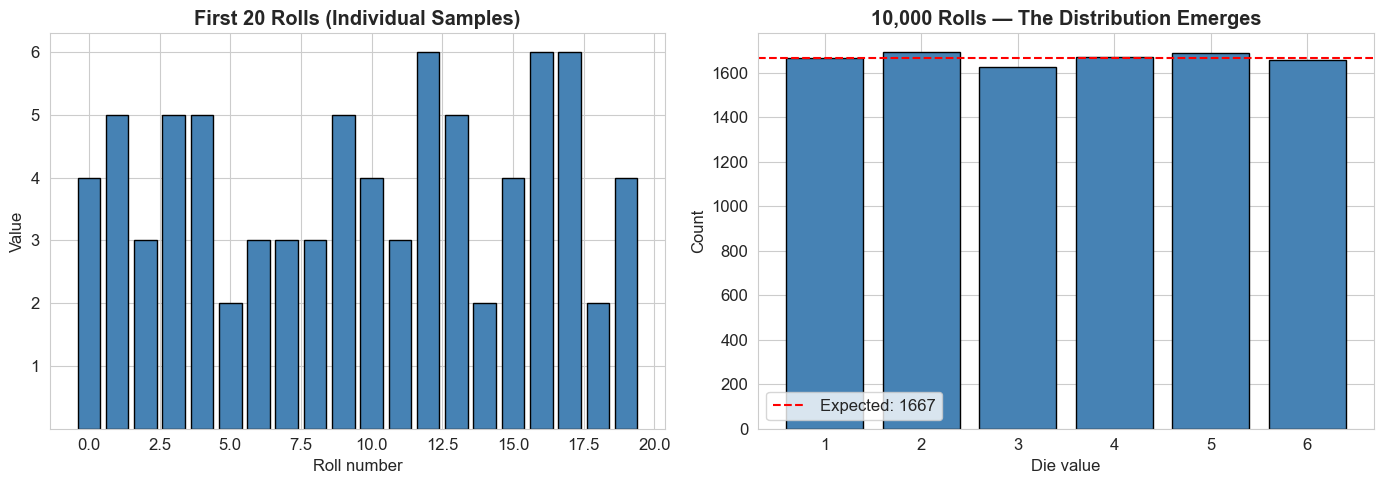

Individual rolls are unpredictable (left).
But the PATTERN of many rolls is predictable (right).
That pattern is the probability distribution.


In [5]:
# ============================================================
# Example 1: Rolling a fair die — a DISCRETE distribution
# ============================================================

# Roll a die 10,000 times
rolls = np.random.randint(1, 7, size=10000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First 20 rolls — individual samples
axes[0].bar(range(20), rolls[:20], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Roll number')
axes[0].set_ylabel('Value')
axes[0].set_title('First 20 Rolls (Individual Samples)', fontweight='bold')
axes[0].set_yticks([1, 2, 3, 4, 5, 6])

# Distribution of all 10,000 rolls
counts = [np.sum(rolls == i) for i in range(1, 7)]
axes[1].bar(range(1, 7), counts, color='steelblue', edgecolor='black')
axes[1].axhline(y=10000/6, color='red', linestyle='--', label=f'Expected: {10000/6:.0f}')
axes[1].set_xlabel('Die value')
axes[1].set_ylabel('Count')
axes[1].set_title('10,000 Rolls — The Distribution Emerges', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Individual rolls are unpredictable (left).")
print("But the PATTERN of many rolls is predictable (right).")
print("That pattern is the probability distribution.")

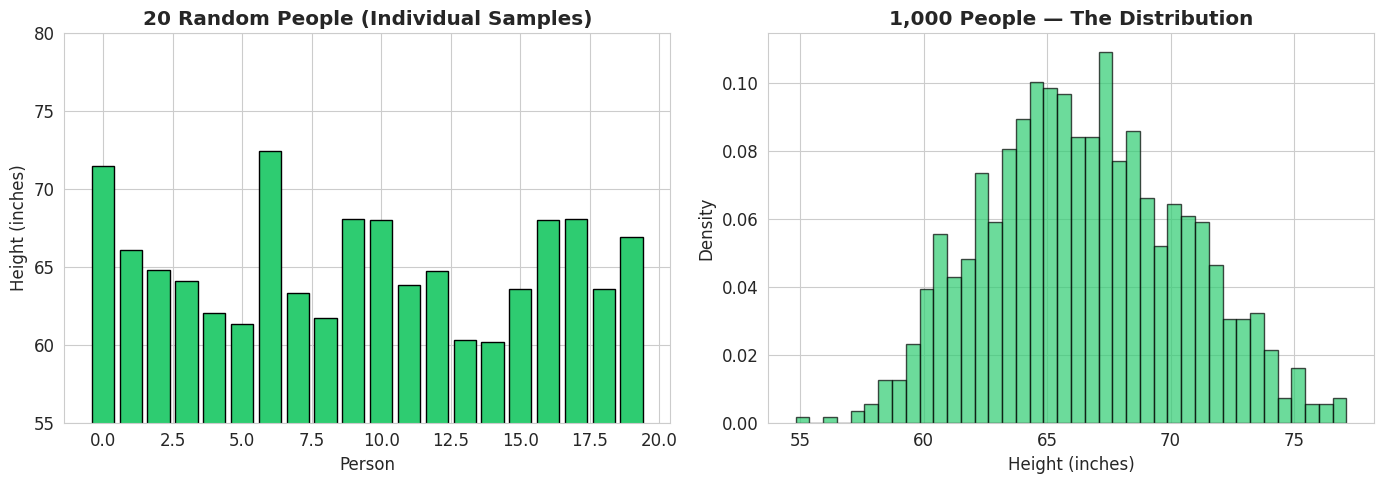

Same idea as the die, but now the values are continuous (not just 1-6).
Most heights cluster around 64-69 inches, with fewer very short or very tall people.
This bell-shaped pattern is the NORMAL (Gaussian) distribution.


In [3]:
# ============================================================
# Example 2: Heights — a CONTINUOUS distribution
# ============================================================

# Simulate heights of 1000 adult Americans (in inches)
# Men ~ N(69.1, 2.9), Women ~ N(63.7, 2.7), roughly 50/50
n = 1000
men_heights = np.random.normal(69.1, 2.9, size=n // 2)
women_heights = np.random.normal(63.7, 2.7, size=n // 2)
all_heights = np.concatenate([men_heights, women_heights])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 20 random people
sample_20 = np.random.choice(all_heights, 20, replace=False)
axes[0].bar(range(20), sample_20, color='#2ecc71', edgecolor='black')
axes[0].set_xlabel('Person')
axes[0].set_ylabel('Height (inches)')
axes[0].set_title('20 Random People (Individual Samples)', fontweight='bold')
axes[0].set_ylim(55, 80)

# Distribution of all 1000
axes[1].hist(all_heights, bins=40, color='#2ecc71', edgecolor='black', alpha=0.7, density=True)
axes[1].set_xlabel('Height (inches)')
axes[1].set_ylabel('Density')
axes[1].set_title('1,000 People — The Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print("Same idea as the die, but now the values are continuous (not just 1-6).")
print("Most heights cluster around 64-69 inches, with fewer very short or very tall people.")
print("This bell-shaped pattern is the NORMAL (Gaussian) distribution.")

### Key Vocabulary

| Term | Meaning | Die Example | Height Example |
|---|---|---|---|
| **Sample** | One observation drawn from the distribution | One roll: "4" | One person: 67.3" |
| **Distribution** | The pattern that emerges from many samples | Equal chance for 1-6 | Bell curve around 66" |
| **Discrete** | Finite set of possible values | 1, 2, 3, 4, 5, 6 | — |
| **Continuous** | Any value in a range | — | 55" to 80" |

**"Sampling from a distribution"** means generating a random value according to that pattern. `np.random.normal(66, 3)` draws one sample from a normal distribution centered at 66 with spread 3.

---

## Part 4: Mean and Standard Deviation — What They Tell You

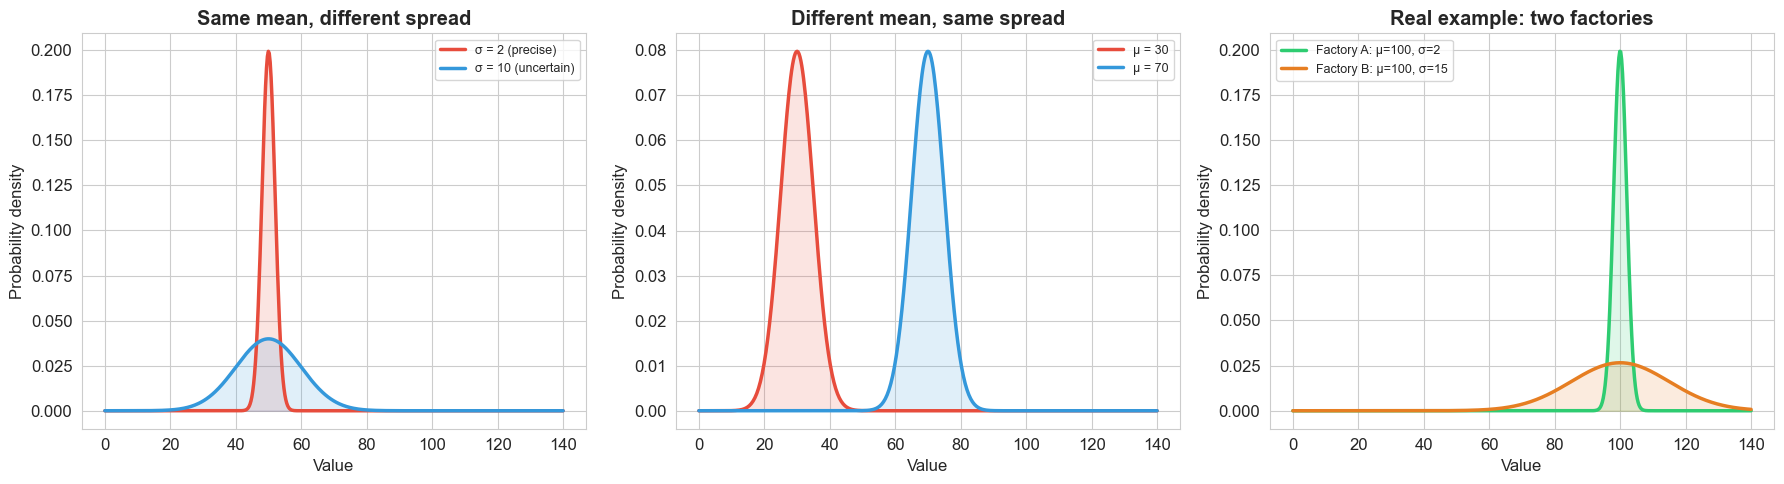

Left: Both centered at 50, but red is much more precise than blue.
Middle: Same spread, but centered at different locations.
Right: Both factories produce 100mm bolts ON AVERAGE, but Factory B
  has way more variation. Which one would you trust for a critical part?


In [6]:
# ============================================================
# The mean tells you WHERE the distribution is centered
# The std tells you HOW SPREAD OUT it is
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scenarios = [
    ('Same mean, different spread', 
     [(50, 2, '#e74c3c', 'σ = 2 (precise)'), 
      (50, 10, '#3498db', 'σ = 10 (uncertain)')]),
    ('Different mean, same spread', 
     [(30, 5, '#e74c3c', 'μ = 30'), 
      (70, 5, '#3498db', 'μ = 70')]),
    ('Real example: two factories', 
     [(100, 2, '#2ecc71', 'Factory A: μ=100, σ=2'), 
      (100, 15, '#e67e22', 'Factory B: μ=100, σ=15')]),
]

for ax, (title, dists) in zip(axes, scenarios):
    x = np.linspace(0, 140, 500)
    for mu, sigma, color, label in dists:
        y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
        ax.plot(x, y, color=color, linewidth=2.5, label=label)
        ax.fill_between(x, y, alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Left: Both centered at 50, but red is much more precise than blue.")
print("Middle: Same spread, but centered at different locations.")
print("Right: Both factories produce 100mm bolts ON AVERAGE, but Factory B")
print("  has way more variation. Which one would you trust for a critical part?")

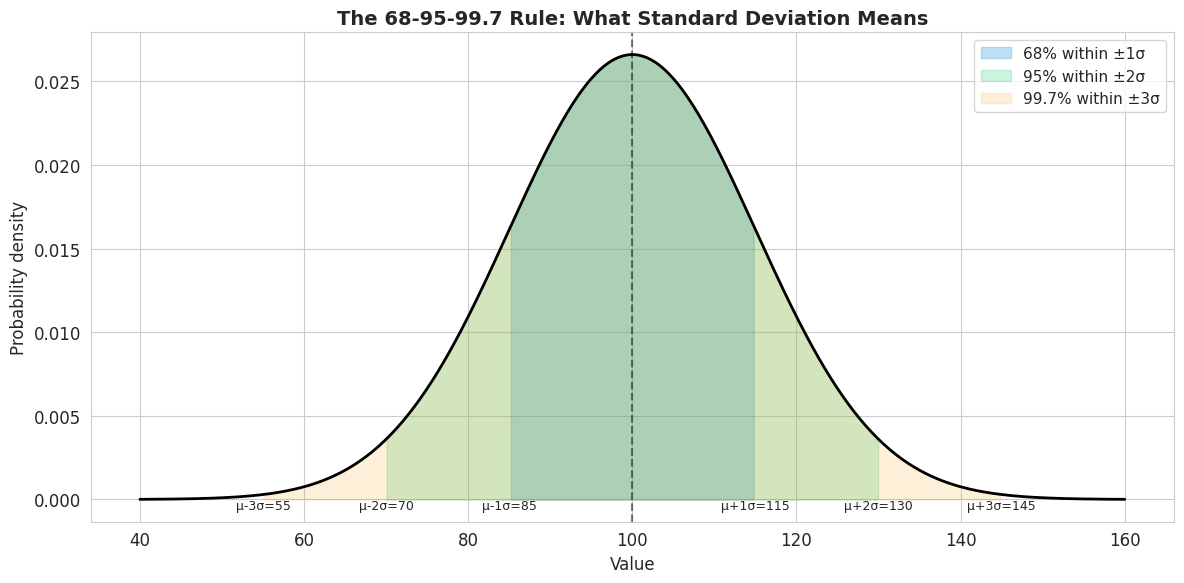

For ANY normal distribution:
  68% of values fall within ±1 standard deviation of the mean
  95% of values fall within ±2 standard deviations
  99.7% of values fall within ±3 standard deviations

This is exactly what the GP uncertainty bands showed:
  ±1σ band captured ~68% of true values
  ±2σ band captured ~95% of true values


In [5]:
# ============================================================
# The 68-95-99.7 rule
# ============================================================
mu, sigma = 100, 15
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, 'black', linewidth=2)

# Fill regions
colors = ['#3498db', '#2ecc71', '#f39c12']
labels = ['68% within ±1σ', '95% within ±2σ', '99.7% within ±3σ']
for i, (n_sigma, color, label) in enumerate(zip([1, 2, 3], colors, labels)):
    mask = (x >= mu - n_sigma*sigma) & (x <= mu + n_sigma*sigma)
    ax.fill_between(x[mask], y[mask], alpha=0.3 - i*0.07, color=color, label=label)

ax.axvline(mu, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Value')
ax.set_ylabel('Probability density')
ax.set_title('The 68-95-99.7 Rule: What Standard Deviation Means', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)

# Annotate
for n_sig in [1, 2, 3]:
    ax.annotate(f'μ+{n_sig}σ={mu+n_sig*sigma}', xy=(mu+n_sig*sigma, 0), 
               fontsize=9, ha='center', va='top')
    ax.annotate(f'μ-{n_sig}σ={mu-n_sig*sigma}', xy=(mu-n_sig*sigma, 0), 
               fontsize=9, ha='center', va='top')

plt.tight_layout()
plt.show()

print("For ANY normal distribution:")
print("  68% of values fall within ±1 standard deviation of the mean")
print("  95% of values fall within ±2 standard deviations")
print("  99.7% of values fall within ±3 standard deviations")
print("\nThis is exactly what the GP uncertainty bands showed:")
print("  ±1σ band captured ~68% of true values")
print("  ±2σ band captured ~95% of true values")

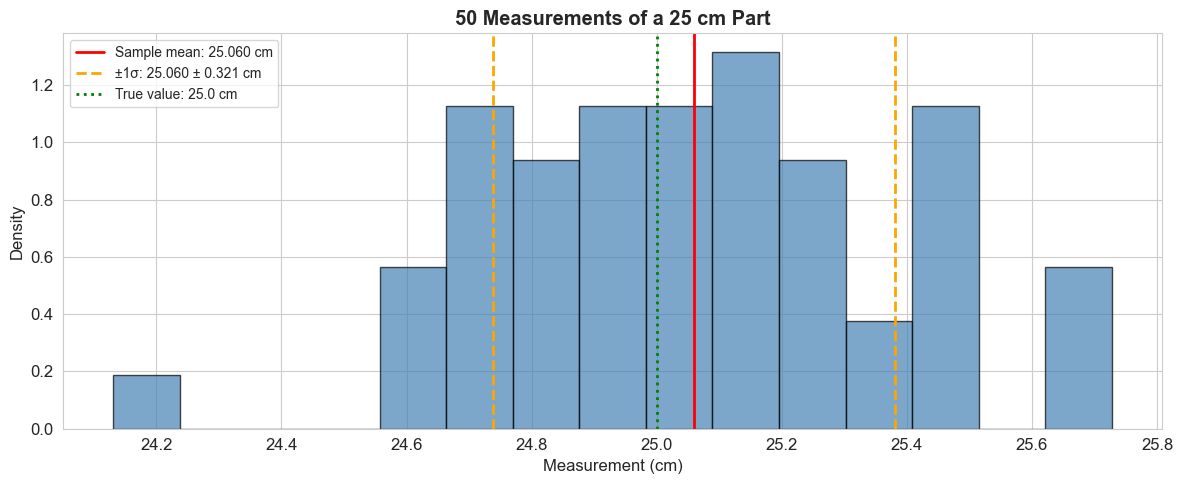

From 50 measurements:
  Mean = 25.0601 cm  (our best estimate of the true value)
  Std  = 0.3213 cm  (how much individual measurements vary)
  True = 25.0000 cm

The mean is close to the true value but not exact.
The std tells us how precise our measurements are.


In [8]:
# ============================================================
# Example: compute mean and std from samples
# ============================================================
# Simulate measuring the same part 50 times with a noisy instrument
true_length = 25.0  # cm
measurements = np.random.normal(true_length, 0.3, size=50)

sample_mean = np.mean(measurements)
sample_std = np.std(measurements, ddof=1)  # ddof=1 for sample std

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(measurements, bins=15, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(sample_mean, color='red', linewidth=2, linestyle='-', label=f'Sample mean: {sample_mean:.3f} cm')
ax.axvline(sample_mean - sample_std, color='orange', linewidth=2, linestyle='--')
ax.axvline(sample_mean + sample_std, color='orange', linewidth=2, linestyle='--', 
           label=f'±1σ: {sample_mean:.3f} ± {sample_std:.3f} cm')
ax.axvline(true_length, color='green', linewidth=2, linestyle=':', label=f'True value: {true_length} cm')

ax.set_xlabel('Measurement (cm)')
ax.set_ylabel('Density')
ax.set_title('50 Measurements of a 25 cm Part', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"From 50 measurements:")
print(f"  Mean = {sample_mean:.4f} cm  (our best estimate of the true value)")
print(f"  Std  = {sample_std:.4f} cm  (how much individual measurements vary)")
print(f"  True = {true_length:.4f} cm")
print(f"\nThe mean is close to the true value but not exact.")
print(f"The std tells us how precise our measurements are.")

---

## Part 5: Sampling — The Foundation of Everything

In Bayesian ML, almost everything is done by **drawing samples from distributions**. Instead of computing an exact answer, you draw many samples and see where they cluster.

Let's build intuition for what sampling looks like with different distributions.

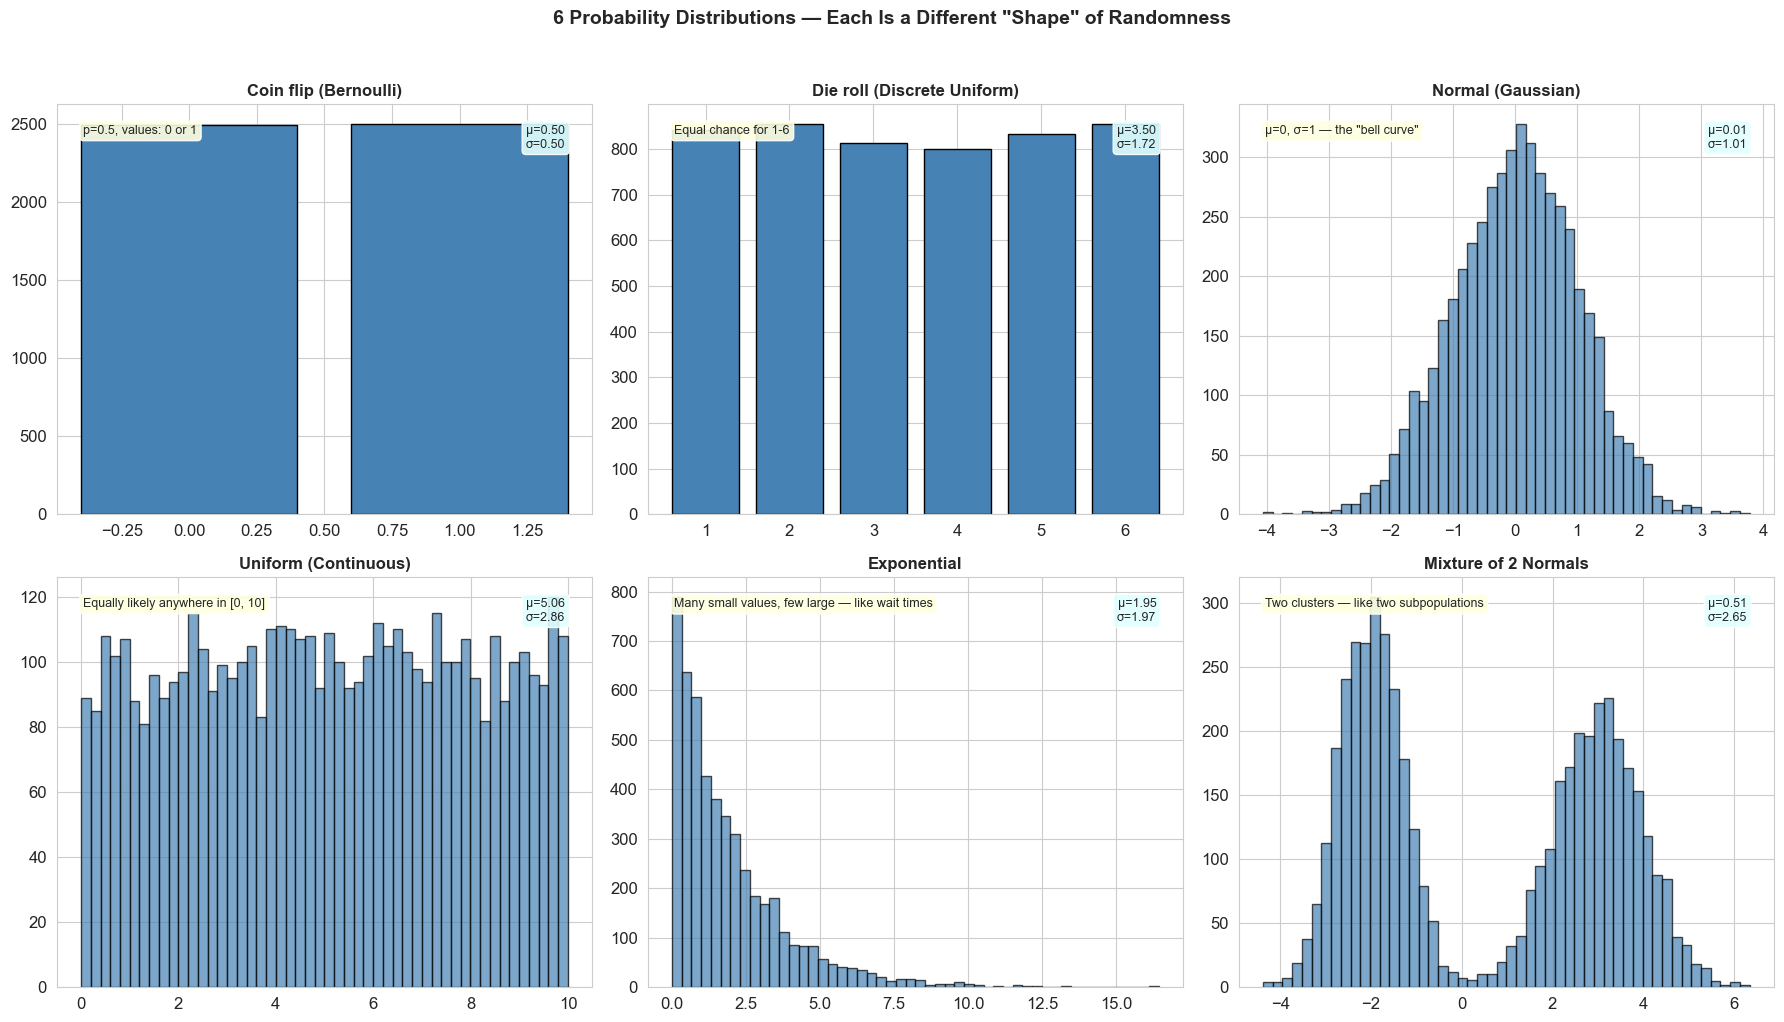

In [9]:
# ============================================================
# Sampling from different distributions
# ============================================================
n_samples = 5000

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

distributions = [
    ('Coin flip (Bernoulli)',
     np.random.binomial(1, 0.5, n_samples),
     'p=0.5, values: 0 or 1'),
    ('Die roll (Discrete Uniform)',
     np.random.randint(1, 7, n_samples),
     'Equal chance for 1-6'),
    ('Normal (Gaussian)',
     np.random.normal(0, 1, n_samples),
     'μ=0, σ=1 — the "bell curve"'),
    ('Uniform (Continuous)',
     np.random.uniform(0, 10, n_samples),
     'Equally likely anywhere in [0, 10]'),
    ('Exponential',
     np.random.exponential(2, n_samples),
     'Many small values, few large — like wait times'),
    ('Mixture of 2 Normals',
     np.concatenate([np.random.normal(-2, 0.7, n_samples//2),
                     np.random.normal(3, 1.0, n_samples//2)]),
     'Two clusters — like two subpopulations'),
]

for ax, (name, samples, desc) in zip(axes.flat, distributions):
    if len(np.unique(samples)) < 10:
        values, counts = np.unique(samples, return_counts=True)
        ax.bar(values, counts, color='steelblue', edgecolor='black')
    else:
        ax.hist(samples, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.text(0.05, 0.95, desc, transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    ax.text(0.95, 0.95, f'μ={np.mean(samples):.2f}\nσ={np.std(samples):.2f}', 
            transform=ax.transAxes, fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9))

plt.suptitle('6 Probability Distributions — Each Is a Different "Shape" of Randomness', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

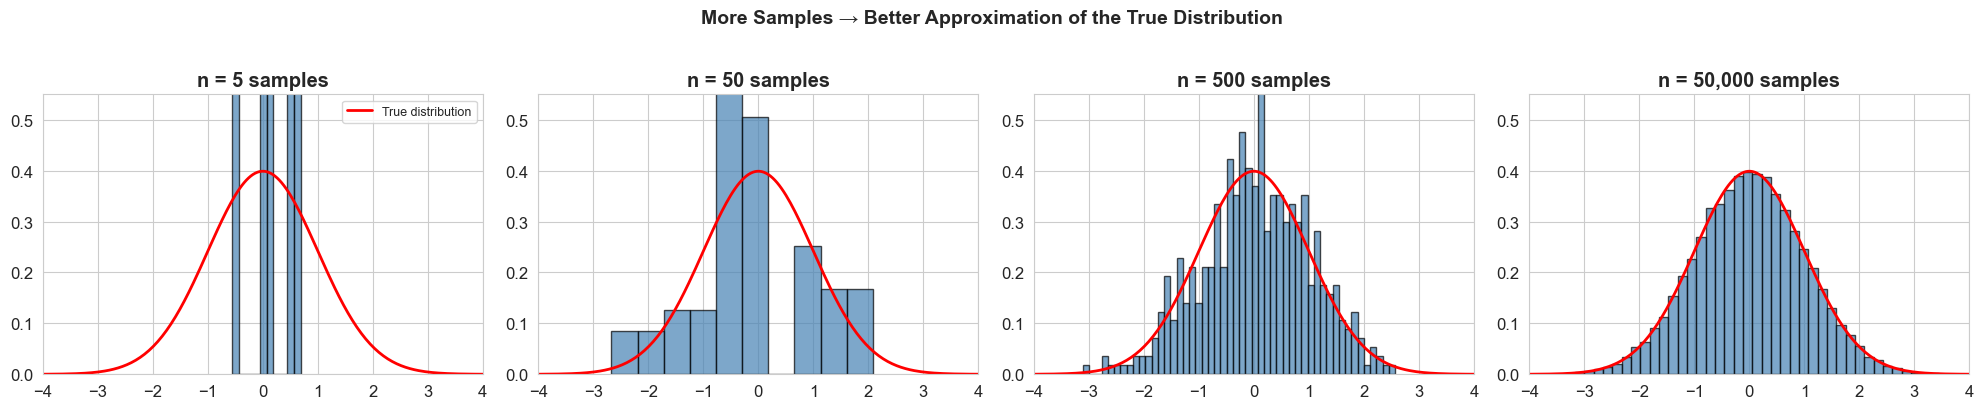

With 5 samples, you can barely tell the shape.
With 50,000, the histogram almost perfectly matches the true curve.

This is exactly what Bayesian methods do: draw enough samples
from a complex distribution to understand its shape.


In [10]:
# ============================================================
# Key insight: more samples = clearer picture
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sample_sizes = [5, 50, 500, 50000]

for ax, n in zip(axes, sample_sizes):
    samples = np.random.normal(0, 1, size=n)
    ax.hist(samples, bins=min(50, max(10, n//5)), color='steelblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Overlay true distribution
    x = np.linspace(-4, 4, 200)
    y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
    ax.plot(x, y, 'red', linewidth=2, label='True distribution')
    
    ax.set_title(f'n = {n:,} samples', fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 0.55)
    if n == 5:
        ax.legend(fontsize=9)

plt.suptitle('More Samples → Better Approximation of the True Distribution', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("With 5 samples, you can barely tell the shape.")
print("With 50,000, the histogram almost perfectly matches the true curve.")
print("\nThis is exactly what Bayesian methods do: draw enough samples")
print("from a complex distribution to understand its shape.")

---

## Part 6: From Sampling to Bayesian Thinking (Preview)

This is where we connect everything to what Michigan will teach next week.

Remember from the UQ notebook: a standard neural network learns **one value** for each weight. A Bayesian neural network learns a **distribution** for each weight.

Let's see what that means concretely.

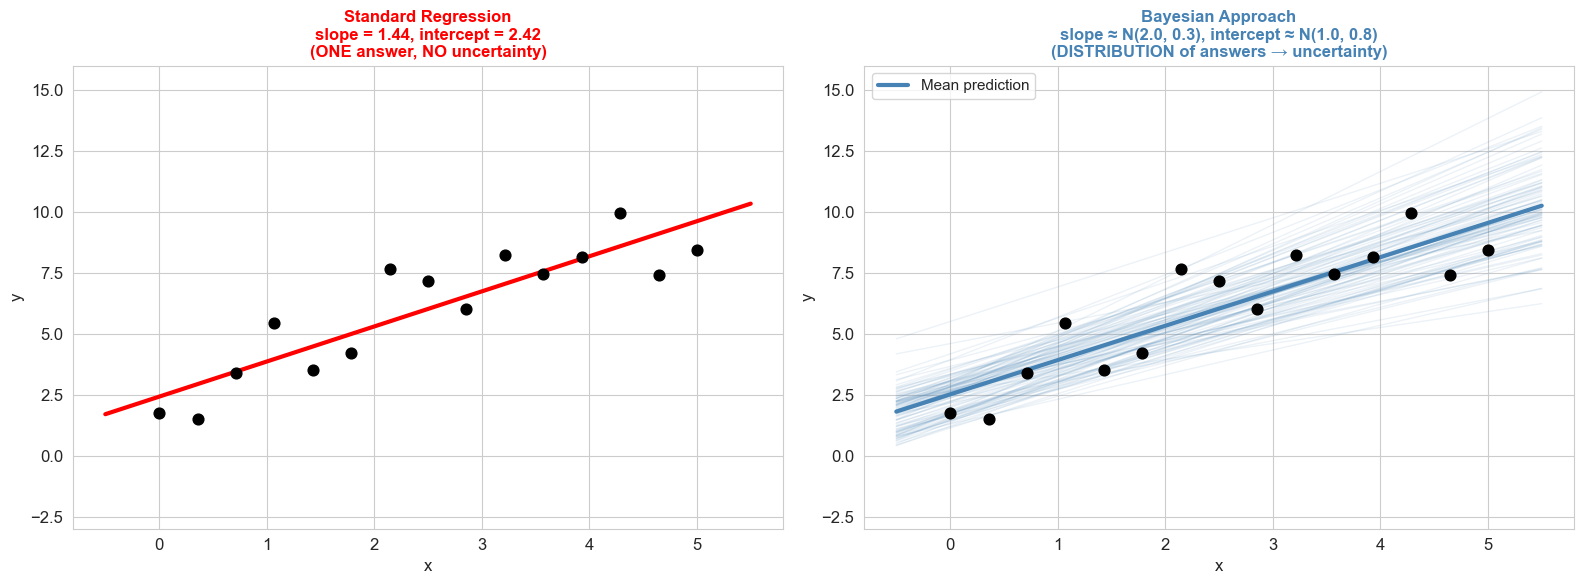

Standard regression: 'The slope is 2.0.' (single number, take it or leave it)
Bayesian regression: 'The slope is probably around 2.0, but could be 1.5 to 2.5.'

The spread of the blue lines IS the uncertainty.
Near the data, the lines agree → low uncertainty.
Far from the data, they diverge → high uncertainty.

This is the same idea as the GP confidence bands!


In [12]:
# ============================================================
# Standard model: one slope, one intercept → one line
# Bayesian model: distribution of slopes/intercepts → many lines
# ============================================================
np.random.seed(42)

# Generate some noisy data
x_data = np.linspace(0, 5, 15)
y_data = 2.0 * x_data + 1.0 + np.random.normal(0, 1.5, len(x_data))

# "Standard" fit: one best line
coeffs = np.polyfit(x_data, y_data, 1)
best_slope, best_intercept = coeffs

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Standard approach: one line ---
ax = axes[0]
ax.scatter(x_data, y_data, c='black', s=60, zorder=5)
x_plot = np.linspace(-0.5, 5.5, 100)
ax.plot(x_plot, best_slope * x_plot + best_intercept, 'red', linewidth=3)
ax.set_title(f'Standard Regression\nslope = {best_slope:.2f}, intercept = {best_intercept:.2f}\n(ONE answer, NO uncertainty)',
             fontweight='bold', fontsize=12, color='red')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_ylim(-3, 16)

# --- Bayesian approach: many plausible lines ---
ax = axes[1]
ax.scatter(x_data, y_data, c='black', s=60, zorder=5)

# Sample many plausible (slope, intercept) pairs from a distribution
n_lines = 100
sampled_slopes = np.random.normal(best_slope, 0.3, n_lines)
sampled_intercepts = np.random.normal(best_intercept, 0.8, n_lines)

for s, i in zip(sampled_slopes, sampled_intercepts):
    ax.plot(x_plot, s * x_plot + i, color='steelblue', alpha=0.1, linewidth=1)

# Mean line
ax.plot(x_plot, np.mean(sampled_slopes) * x_plot + np.mean(sampled_intercepts), 
        'steelblue', linewidth=3, label='Mean prediction')

ax.set_title('Bayesian Approach\nslope ≈ N(2.0, 0.3), intercept ≈ N(1.0, 0.8)\n(DISTRIBUTION of answers → uncertainty)',
             fontweight='bold', fontsize=12, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_ylim(-3, 16)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Standard regression: 'The slope is 2.0.' (single number, take it or leave it)")
print("Bayesian regression: 'The slope is probably around 2.0, but could be 1.5 to 2.5.'")
print("\nThe spread of the blue lines IS the uncertainty.")
print("Near the data, the lines agree → low uncertainty.")
print("Far from the data, they diverge → high uncertainty.")
print("\nThis is the same idea as the GP confidence bands!")

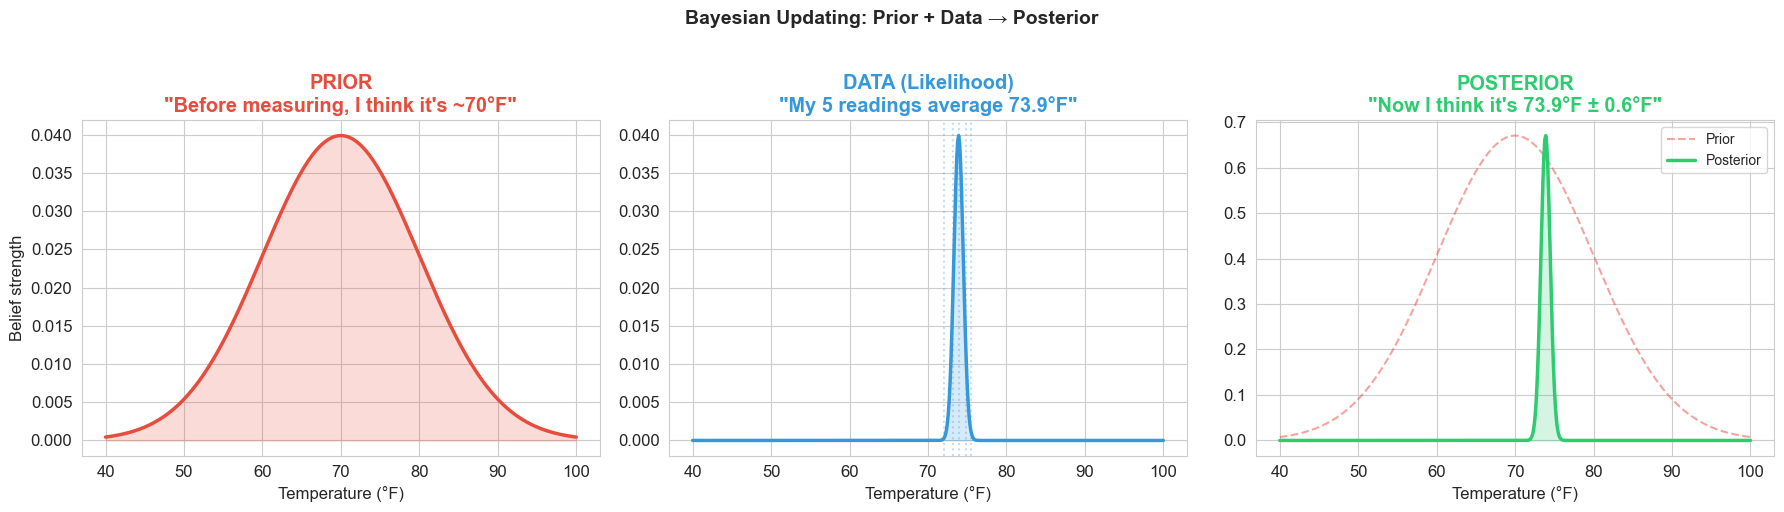

The three-panel story:
  1. PRIOR: Before measuring, you guessed ~70°F ± 10°F (wide, uncertain)
  2. DATA:  Your thermometer readings average 73.9°F
  3. POSTERIOR: Updated belief is 73.9°F ± 0.6°F (narrower, more certain)

Notice the posterior is:
  • Shifted from 70 toward 74 (the data pulled the belief toward the evidence)
  • Narrower than the prior (more data → more confident)
  • Not exactly at 73.9 (the prior still has some influence)
works inside a neural network.

This is the CORE of Bayesian inference: combine prior beliefs with data
to get an updated belief. Next week, Michigan will show you how this


In [19]:
# ============================================================
# Updating beliefs with data: the Bayesian big idea
# ============================================================

# Scenario: you're estimating the true temperature of a room.
# Before measuring, you guess it's probably around 70°F ± 10°F.
# Then you take measurements with a noisy thermometer.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.linspace(40, 100, 500)

# Prior: what you believed before seeing data -- try tweaking the sigma
prior_mu, prior_sigma = 70, 10
prior = (1 / (prior_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - prior_mu) / prior_sigma)**2)

axes[0].plot(x, prior, color='#e74c3c', linewidth=2.5)
axes[0].fill_between(x, prior, alpha=0.2, color='#e74c3c')
axes[0].set_title('PRIOR\n"Before measuring, I think it\'s ~70°F"', fontweight='bold', color='#e74c3c')
axes[0].set_xlabel('Temperature (°F)')
axes[0].set_ylabel('Belief strength')

# Data: thermometer readings
measurements = [73.2, 74.8, 72.1, 75.5, 73.9]  # true temp is 74°F
data_mu = np.mean(measurements)
data_sigma = np.std(measurements, ddof=1) / np.sqrt(len(measurements))  # standard error
likelihood = (1 / (data_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - data_mu) / data_sigma)**2)
likelihood = likelihood / likelihood.max() * prior.max()  # scale for visual comparison

axes[1].plot(x, likelihood, color='#3498db', linewidth=2.5)
axes[1].fill_between(x, likelihood, alpha=0.2, color='#3498db')
for m in measurements:
    axes[1].axvline(m, color='#3498db', alpha=0.3, linestyle=':')
axes[1].set_title(f'DATA (Likelihood)\n"My 5 readings average {data_mu:.1f}°F"', 
                  fontweight='bold', color='#3498db')
axes[1].set_xlabel('Temperature (°F)')

# Posterior: updated belief (prior × likelihood, simplified)
post_precision = 1/prior_sigma**2 + 1/data_sigma**2
post_mu = (prior_mu/prior_sigma**2 + data_mu/data_sigma**2) / post_precision
post_sigma = np.sqrt(1 / post_precision)
posterior = (1 / (post_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - post_mu) / post_sigma)**2)

axes[2].plot(x, prior / prior.max() * posterior.max(), color='#e74c3c', 
             linewidth=1.5, linestyle='--', alpha=0.5, label='Prior')
axes[2].plot(x, posterior, color='#2ecc71', linewidth=2.5, label='Posterior')
axes[2].fill_between(x, posterior, alpha=0.2, color='#2ecc71')
axes[2].set_title(f'POSTERIOR\n"Now I think it\'s {post_mu:.1f}°F ± {post_sigma:.1f}°F"', 
                  fontweight='bold', color='#2ecc71')
axes[2].set_xlabel('Temperature (°F)')
axes[2].legend(fontsize=10)

plt.suptitle('Bayesian Updating: Prior + Data → Posterior', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("The three-panel story:")
print(f"  1. PRIOR: Before measuring, you guessed ~{prior_mu}°F ± {prior_sigma}°F (wide, uncertain)")
print(f"  2. DATA:  Your thermometer readings average {data_mu:.1f}°F")
print(f"  3. POSTERIOR: Updated belief is {post_mu:.1f}°F ± {post_sigma:.1f}°F (narrower, more certain)")
print()
print("Notice the posterior is:")
print("  • Shifted from 70 toward 74 (the data pulled the belief toward the evidence)")
print("  • Narrower than the prior (more data → more confident)")
print("  • Not exactly at 73.9 (the prior still has some influence)")
print("works inside a neural network.")
print()
print("This is the CORE of Bayesian inference: combine prior beliefs with data")
print("to get an updated belief. Next week, Michigan will show you how this")

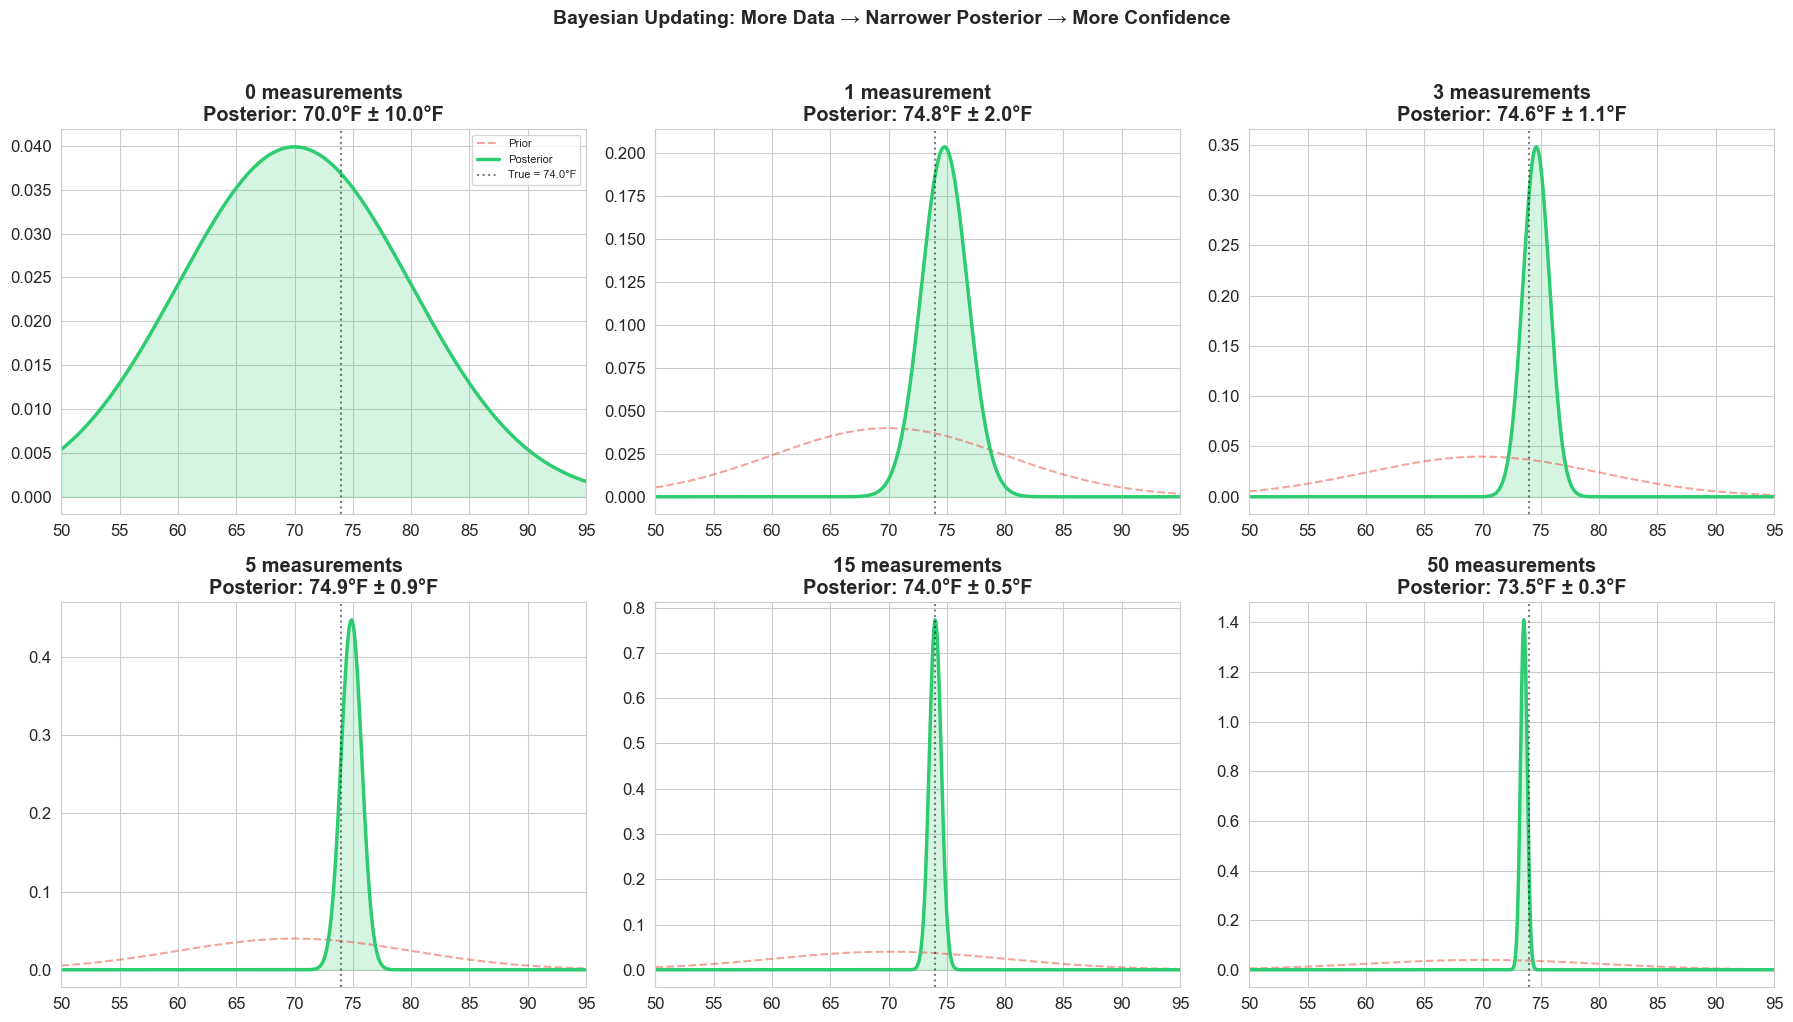

With 0 measurements:  Posterior = Prior (we only have our guess)
With 1 measurement:   Posterior shifts toward the data, but still wide
With 5 measurements:  Posterior is centering on the true temperature
With 50 measurements: Posterior is very tight around 74°F

Key insight: the prior becomes LESS important as you get more data.
With enough evidence, the data overwhelms whatever you believed before.


In [15]:
# ============================================================
# What happens as you collect more data?
# ============================================================
np.random.seed(42)
true_temp = 74.0
all_readings = np.random.normal(true_temp, 2.0, size=50)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
data_counts = [0, 1, 3, 5, 15, 50]

x = np.linspace(50, 95, 500)
prior_mu, prior_sigma = 70, 10

for ax, n in zip(axes.flat, data_counts):
    # Prior
    p_mu, p_sigma = prior_mu, prior_sigma
    
    if n > 0:
        readings = all_readings[:n]
        d_mu = np.mean(readings)
        d_sigma = 2.0 / np.sqrt(n)  # known measurement noise
        
        # Bayesian update
        post_prec = 1/p_sigma**2 + 1/d_sigma**2
        post_mu = (p_mu/p_sigma**2 + d_mu/d_sigma**2) / post_prec
        post_sigma = np.sqrt(1 / post_prec)
    else:
        post_mu, post_sigma = p_mu, p_sigma
    
    # Plot
    prior_curve = (1 / (p_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - p_mu) / p_sigma)**2)
    post_curve = (1 / (post_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - post_mu) / post_sigma)**2)
    
    ax.plot(x, prior_curve, '#e74c3c', linewidth=1.5, linestyle='--', alpha=0.5, label='Prior')
    ax.plot(x, post_curve, '#2ecc71', linewidth=2.5, label='Posterior')
    ax.fill_between(x, post_curve, alpha=0.2, color='#2ecc71')
    ax.axvline(true_temp, color='black', linestyle=':', alpha=0.5, label=f'True = {true_temp}°F')
    
    ax.set_title(f'{n} measurement{"s" if n != 1 else ""}\n'
                 f'Posterior: {post_mu:.1f}°F ± {post_sigma:.1f}°F', fontweight='bold')
    ax.set_xlim(50, 95)
    if n == 0:
        ax.legend(fontsize=8)

plt.suptitle('Bayesian Updating: More Data → Narrower Posterior → More Confidence', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("With 0 measurements:  Posterior = Prior (we only have our guess)")
print("With 1 measurement:   Posterior shifts toward the data, but still wide")
print("With 5 measurements:  Posterior is centering on the true temperature")
print("With 50 measurements: Posterior is very tight around 74°F")
print()
print("Key insight: the prior becomes LESS important as you get more data.")
print("With enough evidence, the data overwhelms whatever you believed before.")

---

## Summary: Some Things We Need for Next Week

When Michigan introduces Bayesian neural networks, here's how today's concepts connect:

| What You Learned Today | How It's Used in Bayesian ML |
|---|---|
| **Sampling from a distribution** | Bayesian NNs draw samples of network weights to make predictions |
| **Mean** | The mean prediction (best guess) |
| **Standard deviation** | The uncertainty around that prediction |
| **Normal distribution** | Weights are often assumed to follow normal distributions |
| **Prior** | What you assume about weights before seeing data (e.g., "probably small, near zero") |
| **Posterior** | What you believe about weights after training on data |
| **More data → narrower posterior** | More training data → more confident predictions |

The Gaussian Process from our UQ notebook was doing exactly this — it maintained a full probability distribution over possible functions and updated it with data. Bayesian neural networks do the same thing, but with the weight distributions inside a neural network.

### Tools Recap

| Tool | Commands to Know |
|---|---|
| **Git** | `status`, `add`, `commit`, `pull`, `push` |
| **uv** | `init`, `run`, `add`, `remove` |